# Aircraft Track Over Radar Data 

The eventual plan for this code is to have an aircraft track plotted over the duration of the radar data file. This will give an idea of where the UND
citation aircraft was at during a given radar scan and eventually will have a gif creation capability. 

In [3]:
# Libraries
import pyart
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import cartopy.feature as cfeature
import xarray as xr
import os
import imageio.v2 as imageio
import pandas as pd
import time

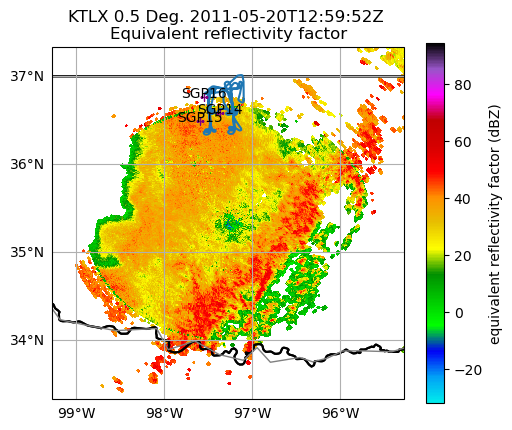

In [24]:
# Flight track over radar data plot
citation_nav = pd.read_csv('2011-05-20_CITATION.dat', sep = ',', header = None)
cit_lat = citation_nav.iloc[:, 2]
cit_lon = citation_nav.iloc[:, 3]

# Reflectivity plotting 
filename = 'KTLX20110520_125935_V03.gz'
data = pyart.io.read('KTLX_May_20_2011/' + filename)

display = pyart.graph.RadarMapDisplay(data)

projection = ccrs.PlateCarree()

center_lon = data.longitude['data'][0]
center_lat = data.latitude['data'][0]

data.latitude['data'][0] = center_lat
data.longitude['data'][0] = center_lon

# Establish min and max latitude and longitude to be plotted:
min_lat = center_lat - 2 #subtracting 1.5 degrees lat
max_lat = center_lat + 2 #adding 1.5 degrees lat
min_lon = center_lon - 2 #subtracting 1.5 degrees lon
max_lon = center_lon + 2 #adding 1.5 degrees lon

fig = plt.figure(figsize = (11,9))

ax = fig.add_axes([0.06, 0.50, 0.40, 0.40], projection = projection)
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth = 1.5, edgecolor = 'black')

a = display.plot_ppi_map('reflectivity', 
                            ax = ax,
                            sweep = 1, 
                            cmap = 'NWSRef', 
                            min_lon = min_lon, 
                            max_lon = max_lon,
                            min_lat = min_lat,
                            max_lat = max_lat)

plt.plot(cit_lon, cit_lat)
#SGP16
plt.annotate('SGP16', xy = (-97.5472, 36.7675),ha = 'center')
plt.plot(-97.5472, 36.7675, marker = '+', color = 'purple')
#SGP15
plt.annotate('SGP15', (-97.593889, 36.49111), ha = 'center')
plt.plot(-97.593889, 36.49111, marker = '+', color = 'purple')
#SGP14
plt.annotate('SGP14', (-97.363611, 36.578611), ha = 'center')
plt.plot(-97.363611, 36.578611, marker = '+', color = 'purple')
plt.show()
#\u2708 is the airplane latex code